Name: Suresh Ghimire
Course: Advanced Big Data and Data Mining (MSCS-634-M20)
Lab: Lab2- Classification Using KNN and RNN Algorithms (Wine Dataset)
Tools Used: Python, Pandas, Sklearn, numpy 

In [1]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from IPython.display import display

# 1) Load dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="class")

print("Dataset shape (X):", X.shape)
print("Target shape (y):", y.shape)

# 2) Basic exploration
display(X.head())

print("\nMissing values per column:")
print(X.isna().sum())

print("\nFeature summary stats:")
display(X.describe())

print("\nClass distribution:")
display(y.value_counts().rename_axis("class").reset_index(name="count"))

# 3) Standardize (z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=wine.feature_names)

print("\nScaled feature summary (should be ~mean 0, std 1):")
display(X_scaled.describe())



Dataset shape (X): (178, 13)
Target shape (y): (178,)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Feature summary stats:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000



Class distribution:


,class,count
0,1,71
1,0,59
2,2,48



Scaled feature summary (should be ~mean 0, std 1):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,178.000000,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02,1.780000e+02
mean,-8.382808e-16,-1.197544e-16,-8.370333e-16,-3.991813e-17,-3.991813e-17,0.000000,-3.991813e-16,3.592632e-16,-1.197544e-16,2.494883e-17,1.995907e-16,3.193450e-16,-1.596725e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00
min,-2.434235e+00,-1.432983e+00,-3.679162e+00,-2.671018e+00,-2.088255e+00,-2.107246,-1.695971e+00,-1.868234e+00,-2.069034e+00,-1.634288e+00,-2.094732e+00,-1.895054e+00,-1.493188e+00
25%,-7.882448e-01,-6.587486e-01,-5.721225e-01,-6.891372e-01,-8.244151e-01,-0.885468,-8.275393e-01,-7.401412e-01,-5.972835e-01,-7.951025e-01,-7.675624e-01,-9.522483e-01,-7.846378e-01
50%,6.099988e-02,-4.231120e-01,-2.382132e-02,1.518295e-03,-1.222817e-01,0.095960,1.061497e-01,-1.760948e-01,-6.289785e-02,-1.592246e-01,3.312687e-02,2.377348e-01,-2.337204e-01
75%,8.361286e-01,6.697929e-01,6.981085e-01,6.020883e-01,5.096384e-01,0.808997,8.490851e-01,6.095413e-01,6.291754e-01,4.939560e-01,7.131644e-01,7.885875e-01,7.582494e-01
max,2.259772e+00,3.109192e+00,3.156325e+00,3.154511e+00,4.371372e+00,2.539515,3.062832e+00,2.402403e+00,3.485073e+00,3.435432e+00,3.301694e+00,1.960915e+00,2.971473e+00


In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# 1) Train K-Means (k=3)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print("Cluster labels (first 20):", cluster_labels[:20])
print("Unique clusters:", sorted(set(cluster_labels)))

# 2) Evaluation metrics
sil_score = silhouette_score(X_scaled, cluster_labels)
ari_score = adjusted_rand_score(y, cluster_labels)

print(f"\nSilhouette Score: {sil_score:.4f}")
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")


Cluster labels (first 20): [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Unique clusters: [np.int32(0), np.int32(1), np.int32(2)]

Silhouette Score: 0.2849
Adjusted Rand Index (ARI): 0.8975


In [3]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

import numpy as np
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils.metric import distance_metric, type_metric
from sklearn.metrics import silhouette_score, adjusted_rand_score

k = 3
data = X_scaled.to_numpy()

# Initial medoids (reproducible random picks)
rng = np.random.default_rng(42)
initial_medoids = rng.choice(len(data), size=k, replace=False).tolist()
metric = distance_metric(type_metric.EUCLIDEAN)
pam = kmedoids(data, initial_medoids, metric=metric)
pam.process()

clusters = pam.get_clusters()

# Convert cluster index lists -> label array
medoid_labels = np.empty(len(data), dtype=int)
for cluster_id, idx_list in enumerate(clusters):
    medoid_labels[idx_list] = cluster_id

print("K-Medoids labels (first 20):", medoid_labels[:20])
print("Unique clusters:", sorted(set(medoid_labels)))

sil_score_med = silhouette_score(data, medoid_labels)
ari_score_med = adjusted_rand_score(y, medoid_labels)

print(f"\nK-Medoids Silhouette Score: {sil_score_med:.4f}")
print(f"K-Medoids Adjusted Rand Index (ARI): {ari_score_med:.4f}")


K-Medoids labels (first 20): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Unique clusters: [np.int64(0), np.int64(1), np.int64(2)]

K-Medoids Silhouette Score: 0.2660
K-Medoids Adjusted Rand Index (ARI): 0.7263


Note: convert centroids/medoids to DataFrame before PCA.transform()

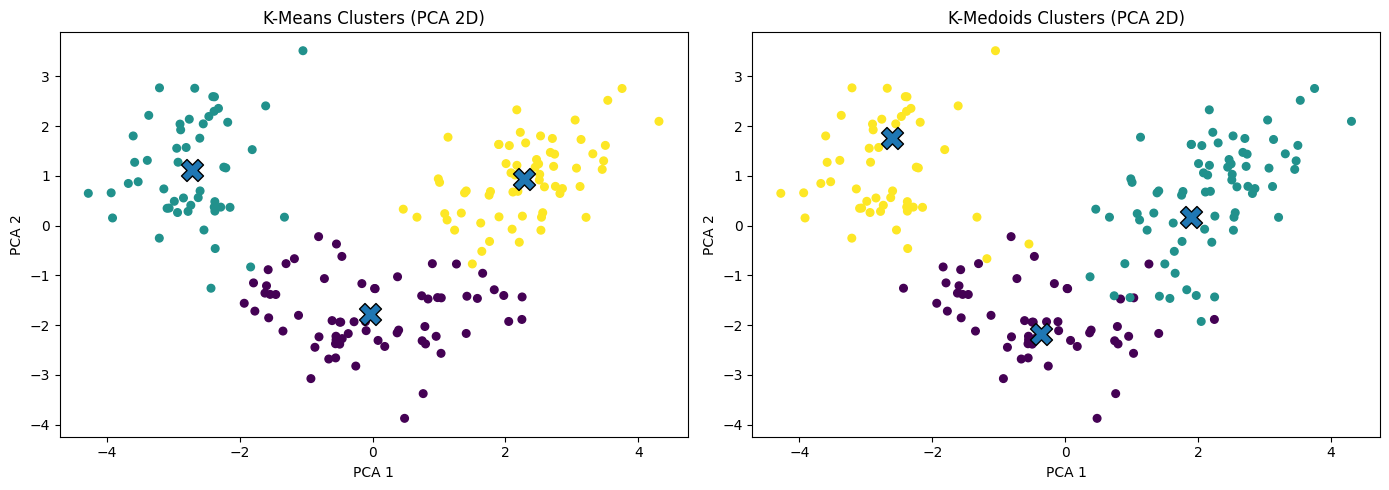

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1) PCA reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

# 2) Get K-Means centroids in PCA space
kmeans_centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=X_scaled.columns)
kmeans_centroids_2d = pca.transform(kmeans_centroids_df)

# 3) Get K-Medoids medoids in PCA space (handles both implementations)
kmedoids_points_2d = None

# If using sklearn-extra KMedoids:
if "kmedoids" in globals() and hasattr(kmedoids, "cluster_centers_"):
    kmedoids_centers_df = pd.DataFrame(kmedoids.cluster_centers_, columns=X_scaled.columns)
    kmedoids_points_2d = pca.transform(kmedoids_centers_df)

# If using pyclustering PAM:
elif "pam" in globals() and hasattr(pam, "get_medoids"):
    medoid_idx = pam.get_medoids()  # indices of medoids in your data
    kmedoids_points_2d = pca.transform(X_scaled.iloc[medoid_idx])

# 4) Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- K-Means plot ---
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, s=30)
axes[0].scatter(kmeans_centroids_2d[:, 0], kmeans_centroids_2d[:, 1],
                marker="X", s=250, edgecolors="black")
axes[0].set_title("K-Means Clusters (PCA 2D)")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")

# --- K-Medoids plot ---
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=medoid_labels, s=30)
if kmedoids_points_2d is not None:
    axes[1].scatter(kmedoids_points_2d[:, 0], kmedoids_points_2d[:, 1],
                    marker="X", s=250, edgecolors="black")
axes[1].set_title("K-Medoids Clusters (PCA 2D)")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")

plt.tight_layout()
plt.show()
